<a href="https://colab.research.google.com/github/junaart/ForStudents/blob/main/Create_portal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Подключение к sqlite

In [ ]:
import sqlite3
try:
    sqlite_connection = sqlite3.connect('portal.db')
    cursor = sqlite_connection.cursor()
    print("База данных создана и успешно подключена к SQLite")

    sqlite_select_query = "select sqlite_version();"
    cursor.execute(sqlite_select_query)
    record = cursor.fetchall()
    print("Версия базы данных SQLite: ", record)
    cursor.close()

except sqlite3.Error as error:
    print("Ошибка при подключении к sqlite", error)
finally:
    if (sqlite_connection):
        sqlite_connection.close()
        print("Соединение с SQLite закрыто")

База данных создана и успешно подключена к SQLite
Версия базы данных SQLite:  [('3.31.1',)]
Соединение с SQLite закрыто


# Структура базы

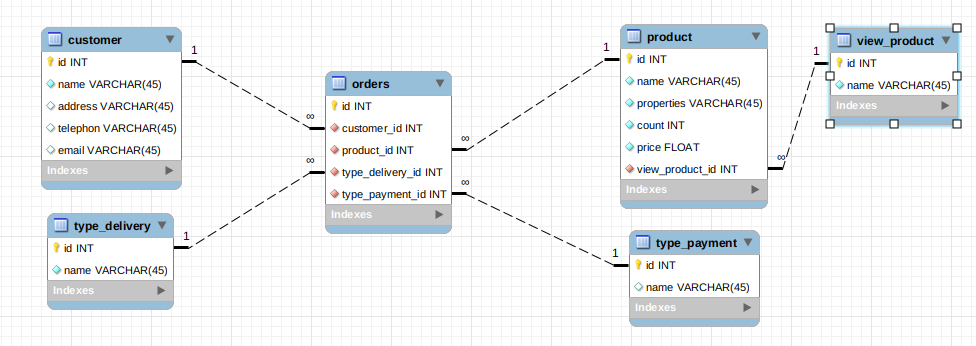

# Создаем базу данных

In [ ]:
import sqlite3
try:
    sqlite_connection = sqlite3.connect('portal.db')

    create_table_type_delivery = '''CREATE TABLE type_delivery
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    name TEXT NOT NULL);'''

    create_table_type_payment = '''CREATE TABLE type_payment
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    name TEXT NOT NULL);'''

    create_table_view_product = '''CREATE TABLE view_product
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    name TEXT NOT NULL);'''

    create_table_customer = '''CREATE TABLE customer
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    name TEXT NOT NULL,
                                    address TEXT NOT NULL,
                                    telephon TEXT NOT NULL,
                                    email TEXT NULL DEFAULT NULL);'''

    create_table_product = '''CREATE TABLE product
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    name TEXT NOT NULL,
                                    properties TEXT NULL DEFAULT NULL,
                                    count INTEGER NOT NULL,
                                    price REAL NOT NULL,
                                    view_product_id INTEGER NOT NULL,
                                    FOREIGN KEY(view_product_id) REFERENCES view_product(id));'''

    create_table_orders = '''CREATE TABLE orders
                                   (id INTEGER NOT NULL PRIMARY KEY,
                                    customer_id INTEGER NOT NULL,
                                    product_id INTEGER NOT NULL,
                                    type_delivery_id INTEGER NOT NULL,
                                    type_payment_id INTEGER NOT NULL,
                                    FOREIGN KEY(product_id) REFERENCES product(id),
                                    FOREIGN KEY(type_delivery_id) REFERENCES type_delivery(id),
                                    FOREIGN KEY(type_payment_id) REFERENCES type_payment(id),
                                    FOREIGN KEY(customer_id) REFERENCES customer(id));'''

    cursor = sqlite_connection.cursor()
    print("База данных подключена к SQLite")
    cursor.execute(create_table_type_delivery)
    sqlite_connection.commit()
    print("Таблица type_delivery создана")
    cursor.execute(create_table_type_payment)
    sqlite_connection.commit()
    print("Таблица type_payment создана")
    cursor.execute(create_table_view_product)
    sqlite_connection.commit()
    print("Таблица view_product создана")
    cursor.execute(create_table_customer)
    sqlite_connection.commit()
    print("Таблица customer создана")
    cursor.execute(create_table_product)
    sqlite_connection.commit()
    print("Таблица product создана")
    cursor.execute(create_table_orders)
    sqlite_connection.commit()
    print("Таблица orders создана")

    cursor.close()

except sqlite3.Error as error:
    print("Ошибка при подключении к sqlite", error)
finally:
    if (sqlite_connection):
        sqlite_connection.close()
        print("Соединение с SQLite закрыто")

База данных подключена к SQLite
Таблица type_delivery создана
Таблица type_payment создана
Таблица view_product создана
Таблица customer создана
Таблица product создана
Таблица orders создана
Соединение с SQLite закрыто


## Интерфейс для заполнения и просмотра справочных таблиц

In [ ]:
#Добавляем данные в type_delivery
sqlite_connection = sqlite3.connect('portal.db')
cursor = sqlite_connection.cursor()
print("Таблица type_delivery (Вид доставки)")
number = 1
while number != 0:
  number = int(input())
  option = input()
  sql = 'INSERT INTO type_delivery (id, name) VALUES(' + str(number)+', \''+ option + '\');'
  if number != 0:
    cursor.execute(sql)
    sqlite_connection.commit()
cursor.close()
sqlite_connection.close()

Таблица type_delivery (Вид доставки)
1
Самовывоз
2
Курьер
0
лл


In [ ]:
#Добавляем данные в type_payment
sqlite_connection = sqlite3.connect('portal.db')
cursor = sqlite_connection.cursor()
print("Таблица type_payment (Вид оплаты)")
number = 1
while number != 0:
  number = int(input())
  option = input()
  sql = 'INSERT INTO type_payment (id, name) VALUES(' + str(number)+', \''+ option + '\');'
  if number != 0:
    cursor.execute(sql)
    sqlite_connection.commit()
cursor.close()
sqlite_connection.close()

Таблица type_payment (Вид оплаты)
1
Безналично
2
Наличными
3
В кредит
0
рр


In [ ]:
#Функция реализует запрос на чтение к базе данных
def query_sql (s):
  sqlite_connection = sqlite3.connect('portal.db')
  cursor = sqlite_connection.cursor()
  cursor.execute(s)
  sqlite_connection.commit()
  rows = cursor.fetchall()
  cursor.close()
  sqlite_connection.close()
  return rows

In [ ]:
print("Просмотр таблицы type_delivery (Вид доставки)")

rows = query_sql('SELECT * FROM type_delivery;')

for row in rows:
  print(row)



Просмотр таблицы type_delivery (Вид доставки)
(1, 'Самовывоз')
(2, 'Курьер')


In [ ]:
print("Просмотр таблицы type_payment (Вид оплаты)")

rows = query_sql('SELECT * FROM type_payment;')

for row in rows:
  print(row)

Просмотр таблицы type_payment (Вид оплаты)
(1, 'Безналично')
(2, 'Наличными')
(3, 'В кредит')


https://colab.research.google.com/notebooks/forms.ipynb#scrollTo=WPib9hvO8Pmb

In [ ]:
import ipywidgets as widgets
from IPython.display import display
button = widgets.Button(description="Click Me!")
output = widgets.Output()

def on_button_clicked(b):
  # Display the message within the output widget.
  with output:
    print("Button clicked.")

button.on_click(on_button_clicked)
display(button, output)

Button(description='Click Me!', style=ButtonStyle())

Output()